In [85]:
import control as ct
import numpy as np
import matplotlib.pyplot as plt

## Define a function to generate a PID controller TF

In [ ]:
def Pid(Kp=None, Ki=None, Kd=None, freq_lpf=None, units=None):
    """Create a PID controller continuous-time transfer function.

    Args:
        Kp: Proportional gain.
        Ki: Integral gain.
        Kd: Derivative gain.
        freq_lpf_Hz: Cutoff frequency of the low-pass filter on the derivative term (in Hz).

    Returns:
        A control.TransferFunction representing the PID controller.
    """
    # proportional term
    if Kp is not None:
        C_p = ct.zpk([], [], Kp)
    else:
        C_p = ct.zpk([], [], 0)

    # integral term
    if Ki is not None:
        C_i = ct.zpk([], 0, Ki)
    else:
        C_i = ct.zpk([], [], 0)

    # derivative term
    if Kd is not None:
        if freq_lpf is not None:  # check for low-pass filter frequency and units
            if units is not None:
                match units:
                    case "Hz":
                        freq_lpf_rad_per_s = freq_lpf
                    case "rad/s":
                        freq_lpf_rad_per_s = 2 * np.pi * freq_lpf
                    case _:
                        raise ValueError("'units' must either be 'Hz' or 'rad/s'")

                C_d = ct.zpk([], [-freq_lpf_rad_per_s], Kd * freq_lpf_rad_per_s)
            else:
                raise ValueError("'units' of frequency must be specified")
        else:
            raise ValueError("A value for Kd was specified, but 'freq_lpf' was not")
    else:
        C_d = ct.zpk([], [], 0)

    # connect transfer functions in parallel
    C_pid = C_p + C_i + C_d
    return C_pid

## Function to generate actuator TF

In [ ]:
def FirstOrderDelay(time_constant, gain=1.0):
    """Create a first-order delay continuous-time transfer function.

    Args:
        time_constant: Time constant of the first-order delay (seconds)
        gain (optional): Gain of the first-order delay transfer function.

    Returns:
        A control.TransferFunction representing the first-order delay.
    """
    return ct.TransferFunction([gain], [time_constant, 1])

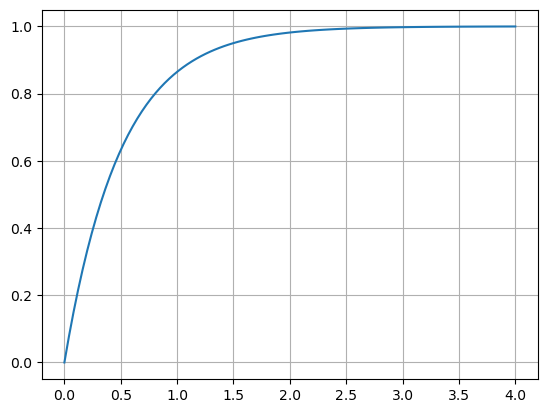

In [ ]:
# test delay
time_constant = 0.5 # 0.4
A = FirstOrderDelay(time_constant)
ct.ss(A)

t, y = ct.forced_response(A, T=np.linspace(0, 4, 100), U=np.ones(100))

plt.plot(t, y)
plt.grid(True)

In [94]:
C_pid = Pid(Kp=1, Ki=0, Kd=2, freq_lpf=10, units="Hz")
print(C_pid)

# C_p = Pid(Kp=2)
# print(f"C_p: {C_p}")

# C_i = Pid(Ki=2)
# print(f"C_i: {C_i}")

# C_d = Pid(Kd=2, freq_lpf=10, units="Hz")
# print(f"C_d: {C_d}")

# print(f"C_pi: {C_p + C_i}")

0 states have been removed from the model
<TransferFunction>: sys[324]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  s + 30
  ------
  s + 10


In [95]:
# convert to continuous-time state space object
C_ct = ct.tf2ss(C_pid)
print(C_ct)

<StateSpace>: sys[324]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (1): ['x[0]']

A = [[-10.]]

B = [[10.]]

C = [[2.]]

D = [[1.]]


In [96]:
# convert to descrete-time
C_dt = ct.c2d(C_ct, 1 / 100)
print(C_dt)
# notice how C and D stay the same

<StateSpace>: sys[324]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (1): ['x[0]']
dt = 0.01

A = [[0.90483742]]

B = [[0.09516258]]

C = [[2.]]

D = [[1.]]


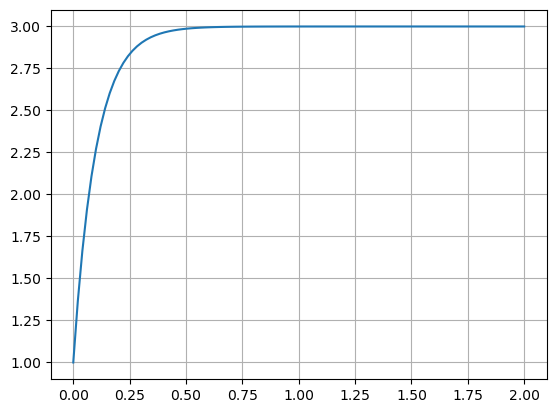

In [97]:
t, y = ct.forced_response(C_pid, T=np.linspace(0, 2, 100), U=np.ones(100))
plt.plot(t, y)
plt.grid(True)

In [93]:
# test the controller
setpoint = 0
x = 1
error = setpoint - x
ctrl_state_0 = np.zeros(len(C_dt.A))  # initialize controller state
u = np.array([error])

N = 200
ctrl_state_k = ctrl_state_0
print(f"control state:\t{ctrl_state_0}")
print(f"output:\t\t{0}")
print(f"input (error):\t{u}\n")
for i in range(N):
    # next controller state (x_kp1 = Ax + Bu)
    ctrl_state_kp1 = C_dt.A @ ctrl_state_k + C_dt.B @ u

    # output of controller (y = Cx + Du)
    y = C_dt.C @ ctrl_state_k + C_dt.D @ u

    print(f"control state:\t{ctrl_state_kp1}")
    print(f"output:\t\t{y}")
    print(f"input (error):\t{u}\n")

    # update state
    ctrl_state_k = ctrl_state_kp1

control state:	[0.]
output:		0
input (error):	[-1]

control state:	[-0.00951626]
output:		[-1.]
input (error):	[-1]

control state:	[-0.01812692]
output:		[-1.09516258]
input (error):	[-1]

control state:	[-0.02591818]
output:		[-1.18126925]
input (error):	[-1]

control state:	[-0.032968]
output:		[-1.25918178]
input (error):	[-1]

control state:	[-0.03934693]
output:		[-1.32967995]
input (error):	[-1]

control state:	[-0.04511884]
output:		[-1.39346934]
input (error):	[-1]

control state:	[-0.05034147]
output:		[-1.45118836]
input (error):	[-1]

control state:	[-0.0550671]
output:		[-1.5034147]
input (error):	[-1]

control state:	[-0.05934303]
output:		[-1.55067104]
input (error):	[-1]

control state:	[-0.06321206]
output:		[-1.59343034]
input (error):	[-1]

control state:	[-0.06671289]
output:		[-1.63212056]
input (error):	[-1]

control state:	[-0.06988058]
output:		[-1.66712892]
input (error):	[-1]

control state:	[-0.07274682]
output:		[-1.69880579]
input (error):	[-1]

control sta